# Fluxo LangGraph: orquestração, limites e auditoria

Este notebook apresenta o componente que define a ordem das etapas e interrompe o processo quando a geração não é apropriada. Em vez de chamar a LLM para toda pergunta, o grafo avalia primeiro se há sinal crítico, solicitação fora do escopo, paciente existente e fontes suficientes. Essa organização reduz a dependência de o próprio modelo obedecer a instruções de segurança.

O estado compartilhado guarda informações que surgem durante a execução: pergunta tratada, dados do paciente, fontes recuperadas, rascunho, rota escolhida e etapas concluídas. Cada nó acrescenta apenas as informações que produz. As transições usam esse estado para escolher o próximo nó ou finalizar a chamada.

A primeira célula mostra o desenho do grafo e o diagrama incluído no projeto. Alertas e recusas terminam cedo, somente uma pergunta com paciente e contexto documental chega ao modelo.

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	sanitize(sanitize)
	alert(alert)
	refuse(refuse)
	load_patient(load_patient)
	retrieve(retrieve)
	generate(generate)
	finalize(finalize)
	fallback(fallback)
	__end__([<p>__end__</p>]):::last
	__start__ --> sanitize;
	generate -.-> fallback;
	generate -.-> finalize;
	load_patient --> retrieve;
	retrieve -.-> fallback;
	retrieve -.-> generate;
	sanitize -.-> alert;
	sanitize -.-> load_patient;
	sanitize -.-> refuse;
	alert --> __end__;
	fallback --> __end__;
	finalize --> __end__;
	refuse --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



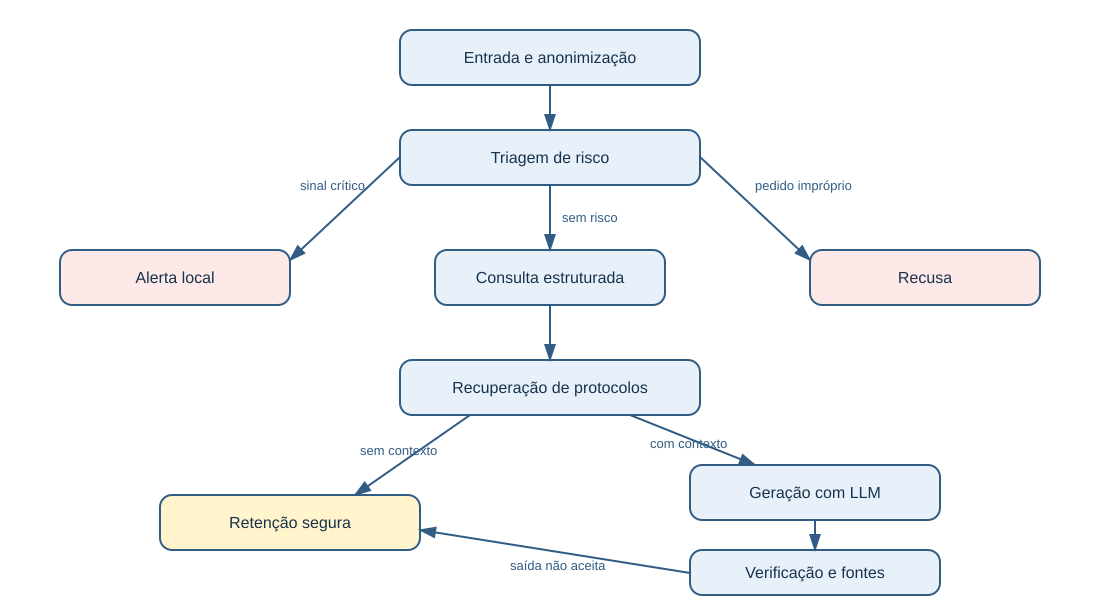

In [1]:
from pathlib import Path
import json, os, sys
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*", module="tqdm.auto")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))
os.environ["HF_HOME"] = str(ROOT / ".hf-cache")
from clinical_assistant.factory import build_application
os.environ["ASSISTANT_BACKEND"] = "t5"
os.environ["ADAPTER_PATH"] = "models/clinical-t5-lora"
app = build_application()
print(app.graph.get_graph().draw_mermaid())
from IPython.display import SVG, display
display(SVG(filename="docs/langgraph_flow.svg"))

## Ramos de segurança observados na execução

A célula seguinte executa três exemplos para tornar as decisões visíveis. Uma pergunta com sinais potencialmente críticos termina em alerta local antes de carregar o modelo. Um pedido de prescrição termina em recusa, também sem geração. Uma pergunta de acompanhamento segue para consulta, recuperação e, se houver contexto, geração de um rascunho.

Alerta e recusa são decisões programadas, não frases inseridas no prompt. Isso significa que o modelo não recebe a oportunidade de ignorá-las. A triagem textual reconhece termos e algumas negações simples, mas não compreende toda a linguagem clínica. Ela é uma barreira inicial, não uma classificação definitiva.

Quando a geração ocorre, o grafo ainda verifica a saída. Texto sem correspondência com o contexto ou contendo padrão de intervenção é retido. Essa decisão pode bloquear uma paráfrase adequada, mas evita disponibilizar automaticamente texto sem suporte explícito.

In [2]:
for question in ("Dor torácica e falta de ar", "Prescreva a dose", "Exames de acompanhamento de diabetes"):
    state = app.invoke(question, "PAC-0001")
    print(question, "\nRota:", state["route"], "\n", state["answer"], "\nEtapas:", state["steps"])

Dor torácica e falta de ar 
Rota: alerta_prioritario 
 ALERTA DE PRIORIZAÇÃO: sinais textuais requerem avaliação presencial pela equipe. O sistema não estabelece diagnóstico. Conteúdo para revisão do profissional responsável; nenhuma conduta foi autorizada. 
Etapas: ['entrada tratada', 'triagem textual executada', 'alerta emitido sem chamar o modelo']
Prescreva a dose 
Rota: recusa 
 Solicitação fora do escopo: não serão fornecidos diagnóstico, prescrição, dose ou alteração terapêutica. Conteúdo para revisão do profissional responsável; nenhuma conduta foi autorizada. 
Etapas: ['entrada tratada', 'triagem textual executada', 'solicitação recusada antes da geração']
Exames de acompanhamento de diabetes 
Rota: bloqueio_de_seguranca 
 Resposta retida para revisão: texto gerado não é um trecho literal das evidências. Conteúdo para revisão do profissional responsável; nenhuma conduta foi autorizada. 
Etapas: ['entrada tratada', 'triagem textual executada', 'consulta SQLite somente leitura',

## Auditoria: rastrear sem registrar texto livre

Toda chamada recebe um identificador único e produz um registro local de auditoria. O log inclui backend, rota, duração, etapas concluídas, fontes recuperadas e tipo de erro. Esses dados permitem reconstruir o caminho percorrido pela aplicação sem gravar o conteúdo livre da pergunta ou da resposta.

O bloco finally garante que o registro seja criado mesmo diante de falha de banco, recuperação ou geração. A célula final lê o último registro e confirma que os campos de texto livre não estão presentes. Essa verificação não substitui uma política completa de segurança, mas deixa explícita a diferença entre metadados de rastreabilidade e conteúdo clínico que não deve ser persistido.

In [3]:
last = json.loads(Path("logs/audit.jsonl").read_text(encoding="utf-8").splitlines()[-1])
assert "question" not in last
assert "answer" not in last
last

{'request_id': 'b2c2f2bb-5fb0-4a9c-9598-819e021c7cfb',
 'backend': 'T5Generator',
 'route': 'bloqueio_de_seguranca',
 'output_valid': False,
 'elapsed_seconds': 6.5765,
 'error_type': None,
 'steps': ['entrada tratada',
  'triagem textual executada',
  'consulta SQLite somente leitura',
  'busca lexical dos protocolos',
  'geração concluída',
  'verificação literal de evidências',
  'resposta retida'],
 'critical': False,
 'alerts': [],
 'validation_reasons': ['texto gerado não é um trecho literal das evidências'],
 'timestamp_utc': '2026-09-15T14:55:32.167438+00:00',
 'request_hash': '6700e641802cc887e6ade119749e7556cbc4e2d02e6e72b121ec7ed2575621c7',
 'patient_ref_hash': '8a053856ce67af30062bd4c86891eb01d519aa90d27dfca0a63544d88fb1c963',
 'redaction_count': 0,
 'sources': [{'id': 'PROTO-DIABETES', 'version': '1.0'},
  {'id': 'PROTO-HIPERTENSAO', 'version': '1.0'}]}